# Construcción del modelo de clasificación de vinos

**Objetivo:** construir y entrenar un modelo de Machine Learning usando el dataset `Wine` de scikit-learn y guardar el Pipeline entrenado como `modelo_wine.pkl`.

Las etiquetas **Cabernet, Merlot y Pinot Noir** se usan solamente con fines didácticos para representar las tres clases del dataset.

## Paso 1. Importar las librerías

In [15]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

## Paso 2. Cargar el dataset

In [16]:
wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)
df["target"] = wine.target

print("Primeros registros:")
display(df.head())

Primeros registros:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## Paso 3. Asignar nombres a las clases

In [17]:
etiquetas = {
    0: "Cabernet",
    1: "Merlot",
    2: "Pinot Noir"
}

df["tipo_vino"] = df["target"].map(etiquetas)

display(df[["target", "tipo_vino"]].head())

,target,tipo_vino
0,0,Cabernet
1,0,Cabernet
2,0,Cabernet
3,0,Cabernet
4,0,Cabernet


## Paso 4. Exploración inicial

Se revisan las dimensiones, cantidad de variables, tipos de datos, valores nulos, estadísticas descriptivas y registros por clase.

In [18]:
print("Dimensiones del dataset:", df.shape)
print("\nCantidad de variables:", df.shape[1])

print("\nTipos de datos:")
print(df.dtypes)

print("\nValores nulos por columna:")
print(df.isnull().sum())

print("\nEstadísticas descriptivas:")
display(df.describe())

print("\nCantidad de registros por tipo de vino:")
print(df["tipo_vino"].value_counts())

Dimensiones del dataset: (178, 15)

Cantidad de variables: 15

Tipos de datos:
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
tipo_vino                        object
dtype: object

Valores nulos por columna:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanth

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000



Cantidad de registros por tipo de vino:
tipo_vino
Merlot        71
Cabernet      59
Pinot Noir    48
Name: count, dtype: int64


### Respuestas del análisis del Paso 4

- **¿Existen valores faltantes?** No. El dataset Wine de scikit-learn no presenta valores nulos en estas variables.
- **¿Las tres clases contienen la misma cantidad de registros?** No. Las clases tienen cantidades distintas.
- **¿Hay diferencias importantes entre las escalas?** Sí. Por ejemplo, `proline` maneja valores mucho mayores que `alcohol` o `malic_acid`, por eso conviene escalar los datos.

## Paso 5. Definir las variables del modelo

In [19]:
caracteristicas = [
    "alcohol",
    "malic_acid",
    "color_intensity",
    "proline"
]

X = df[caracteristicas]
y = df["tipo_vino"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

display(X.head())
display(y.head())

Dimensiones de X: (178, 4)
Dimensiones de y: (178,)


,alcohol,malic_acid,color_intensity,proline
0,14.23,1.71,5.64,1065.0
1,13.20,1.78,4.38,1050.0
2,13.16,2.36,5.68,1185.0
3,14.37,1.95,7.80,1480.0
4,13.24,2.59,4.32,735.0


,tipo_vino
0,Cabernet
1,Cabernet
2,Cabernet
3,Cabernet
4,Cabernet


## Paso 6. Crear los conjuntos de entrenamiento y prueba

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (142, 4)
X_test: (36, 4)
y_train: (142,)
y_test: (36,)


### Respuestas del análisis del Paso 6

- **¿Por qué no se usa el 100 % de los datos para entrenar?** Porque necesitamos reservar datos que el modelo no haya visto para evaluar qué tan bien generaliza.
- **¿Qué función cumple la estratificación?** Mantiene aproximadamente la misma proporción de cada clase tanto en entrenamiento como en prueba.

## Pasos 7 y 8. Construir el Pipeline y entrenar el modelo

In [21]:
modelo = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear"))
])

modelo.fit(X_train, y_train)

print("Clases aprendidas por el modelo:")
print(modelo.named_steps["svm"].classes_)

Clases aprendidas por el modelo:
['Cabernet' 'Merlot' 'Pinot Noir']


### ¿Por qué conviene incluir el escalamiento y el modelo dentro del mismo Pipeline?

Porque así el escalamiento y la clasificación se aplican siempre en el mismo orden. Además, evita errores al usar datos nuevos y ayuda a prevenir fuga de información entre entrenamiento y prueba.

## Paso 9. Realizar predicciones

In [22]:
y_pred = modelo.predict(X_test)

comparacion = pd.DataFrame({
    "Real": y_test.values,
    "Predicho": y_pred
})

display(comparacion.head(15))

,Real,Predicho
0,Cabernet,Cabernet
1,Pinot Noir,Merlot
2,Cabernet,Cabernet
3,Merlot,Pinot Noir
4,Merlot,Merlot
5,Cabernet,Cabernet
6,Cabernet,Cabernet
7,Merlot,Merlot
8,Merlot,Merlot
9,Pinot Noir,Pinot Noir


## Paso 10. Evaluar el modelo

In [23]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nReporte por clase:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy:  0.9167
Precision: 0.9173
Recall:    0.9167
F1-score:  0.9159

Reporte por clase:
              precision    recall  f1-score   support

    Cabernet       1.00      1.00      1.00        12
      Merlot       0.87      0.93      0.90        14
  Pinot Noir       0.89      0.80      0.84        10

    accuracy                           0.92        36
   macro avg       0.92      0.91      0.91        36
weighted avg       0.92      0.92      0.92        36



### Interpretación

- **Accuracy:** proporción total de predicciones correctas.
- **Precision:** qué tan confiables son las predicciones de cada clase.
- **Recall:** qué proporción de los casos reales de cada clase logra detectar el modelo.
- **F1-score:** balance entre precision y recall.

El `classification_report` permite revisar estas métricas para Cabernet, Merlot y Pinot Noir por separado.

## Paso 11. Matriz de confusión

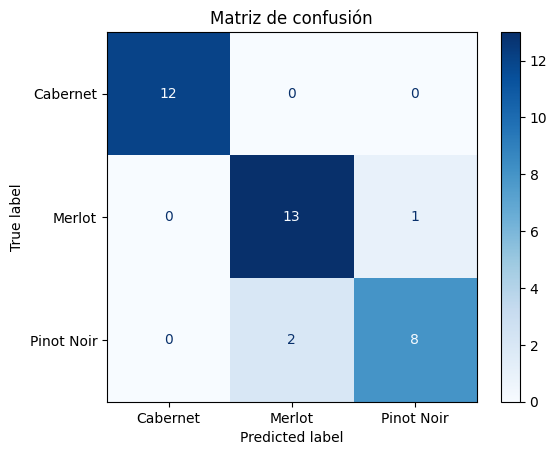

In [24]:
orden_clases = ["Cabernet", "Merlot", "Pinot Noir"]

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=orden_clases,
    display_labels=orden_clases,
    cmap="Blues"
)

plt.title("Matriz de confusión")
plt.show()

### Cómo interpretar la matriz

Los valores de la diagonal representan predicciones correctas.  
Los valores fuera de la diagonal muestran errores de clasificación entre las clases.

## Paso 12. Probar un nuevo vino

In [25]:
nuevo_vino = pd.DataFrame([{
    "alcohol": 13.5,
    "malic_acid": 1.8,
    "color_intensity": 5.2,
    "proline": 1000
}])

prediccion_nuevo = modelo.predict(nuevo_vino)[0]

print("Predicción para el nuevo vino:", prediccion_nuevo)

Predicción para el nuevo vino: Cabernet


## Paso 13. Guardar el modelo como `modelo_wine.pkl`

In [26]:
nombre_archivo = "modelo_wine.pkl"

joblib.dump(modelo, nombre_archivo)

print("Archivo generado:", os.path.exists(nombre_archivo))
print("Nombre:", nombre_archivo)

Archivo generado: True
Nombre: modelo_wine.pkl


### Descargar el `.pkl` en Google Colab

Después de ejecutar la celda anterior, puedes descargarlo con:

In [27]:
from google.colab import files
files.download("modelo_wine.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Paso 14. Recuperar el modelo

In [28]:
modelo_recuperado = joblib.load("modelo_wine.pkl")

prediccion_recuperada = modelo_recuperado.predict(nuevo_vino)[0]

print("Predicción antes de guardar: ", prediccion_nuevo)
print("Predicción después de cargar:", prediccion_recuperada)
print("¿Coinciden?:", prediccion_nuevo == prediccion_recuperada)

Predicción antes de guardar:  Cabernet
Predicción después de cargar: Cabernet
¿Coinciden?: True


## Reflexión final

**Entrenar un modelo** significa usar datos de ejemplo para que el algoritmo aprenda patrones y ajuste sus parámetros.

**Utilizar un modelo previamente entrenado** significa cargar un modelo que ya aprendió esos patrones y usarlo directamente para hacer nuevas predicciones, sin volver a entrenarlo.

**Flujo completo:**  
Datos → preparación → Pipeline → entrenamiento → evaluación → Joblib → `modelo_wine.pkl`